In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Data Loading

In [2]:
cols = [
    'stay_id', 
    'timestep',    
    'sepsis',
    
    'age',         # strongly correlates with baseline vulnerability and immune capability.
    'gender',      # helps account for baseline physiological differences.
    'charlson_comorbidity_index', # summary score of prior illnesses: sets the baseline health/risk profile.
    
    # vitals
    'heart_rate',       # BPM: high HR is a primary physiological sign of distress.
    'map',              # Mean Arterial Pressure: indicator of overall blood flow and hemodynamic shock.
    'respiratory_rate', # Breaths per minute: fast breathing is an early warning sign.
    'temp_C',           # Body temperature (Celsius): fever or hypothermia are responses to infection.
    'spo2',             # Oxygen saturation: essential for identifying difficulty in breathing.
    
    # labs
    'wbc',         # White Blood Cell count: marker of the body preparing an immune response.
    'lactate',     # Blood lactate: gold standard indicator of tissue oxygen starvation and septic shock.
    # 'lactic_acid', # Same as lactate (from a different table), could be used to imputing missng lactate
    'creatinine',  # Kidney function marker: kidney injury is a common symptom in sepsis.
    'platelets',   # Blood clotting cells: sepsis often causes dangerous drops in platelets.
    
    # derived scores - maybe won't be used, as the model should learn these itself
    'sirs_score', 
    'shock_index'
]

In [3]:
data = pd.read_parquet('../../data/processed_files/patient_timeseries_v4_v2.parquet')[cols]
data['stay_id'] = data['stay_id'].astype(int)
data.set_index(['stay_id', 'timestep'], inplace=True)
print(f'number of stays: {data.index.get_level_values("stay_id").nunique()}')
print(data.columns)

if not data.isnull().any().any():
    print('no missing values!')
else:
    print('missing values:')
    print(data.isnull().sum())

data.head()

number of stays: 83279
Index(['sepsis', 'age', 'gender', 'charlson_comorbidity_index', 'heart_rate',
       'map', 'respiratory_rate', 'temp_C', 'spo2', 'wbc', 'lactate',
       'creatinine', 'platelets', 'sirs_score', 'shock_index'],
      dtype='str')
no missing values!


sepsis   age  gender  charlson_comorbidity_index  \
stay_id  timestep                                                     
30000153 1              0  61.0       0                           2   
         2              0  61.0       0                           2   
         3              0  61.0       0                           2   
         4              0  61.0       0                           2   
         5              0  61.0       0                           2   

                   heart_rate   map  respiratory_rate     temp_C        spo2  \
stay_id  timestep                                                              
30000153 1         102.000000  85.7         15.692308  36.283951  100.000000   
         2          93.400000  77.9         16.300000  37.388889   99.900000   
         3         122.800000  87.2         19.400000  38.077778   96.400000   
         4         110.600000  82.8         13.000000  37.644444   95.400000   
         5         105.666667  92.5         10.666667  37.361111   93.833333   

                    wbc   lactate  creatinine   platelets  sirs_score  \
stay_id  timestep                                                       
30000153 1          9.2  1.566667    1.000000  199.000000           1   
         2         17.0  2.100000    0.900000  173.000000           2   
         3         17.0  2.100000    0.900000  173.000000           3   
         4         17.0  1.600000    0.900000  173.000000           2   
         5         15.5  1.600000    1.066667  163.833333           3   

                   shock_index  
stay_id  timestep               
30000153 1            0.751658  
         2            0.775748  
         3            0.889855  
         4            0.905074  
         5            0.717195

# Sanity Checks

In [4]:
patient_outcomes = data.groupby('stay_id')['sepsis'].max()

never_sepsis_count = (patient_outcomes == 0).sum()
got_sepsis_count = (patient_outcomes > 0).sum()

total_patients = data.index.get_level_values('stay_id').nunique()

print(f"Total unique patients: {total_patients:,}")
print(f"Patients who never get sepsis: {never_sepsis_count:,} ({(never_sepsis_count/total_patients)*100:.2f}%)")
print(f"Patients who get sepsis: {got_sepsis_count:,} ({(got_sepsis_count/total_patients)*100:.2f}%)")

Total unique patients: 83,279
Patients who never get sepsis: 52,736 (63.32%)
Patients who get sepsis: 30,543 (36.68%)


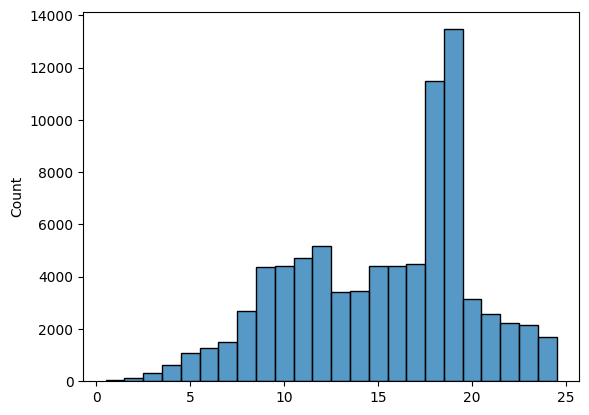

In [5]:
# trajectory length
# the spike at 18/19 is as the majority of patients don't have (or only 1 timestep) data prior to 
# ICU admission, so their first timestep is in ICU, and we use a 72hr post admission window
# which is 72/4=18 4hr timesteps

sns.histplot(data.groupby('stay_id').size(), discrete=True)
plt.show()

In [6]:
# no 0s after a 2, no 2 before a 1
def check_label_ordering(group):
    labels = group['sepsis'].values
    first_1 = next((i for i, v in enumerate(labels) if v == 1), None)
    first_2 = next((i for i, v in enumerate(labels) if v == 2), None)
    if first_1 is not None and first_2 is not None:
        return first_1 < first_2
    return True

septic_stays = data[data['sepsis'] > 0].groupby('stay_id')
ordering_ok = septic_stays.apply(check_label_ordering)
print(f"Correct 0→1→2 ordering: {ordering_ok.sum()}/{len(ordering_ok)} stays")

Correct 0→1→2 ordering: 30543/30543 stays


# Outlier Handling

In [7]:
# check clinical ranges 
clinical_ranges = {
    'heart_rate':       (20, 250),
    'map':              (20, 180),
    'respiratory_rate': (4, 60),
    'temp_C':           (32, 42),
    'spo2':             (50, 100),
    'wbc':              (0.1, 100),
    'lactate':          (0.1, 20),
    'creatinine':       (0.1, 20),
    'platelets':        (1, 1500),
}

for col, (lo, hi) in clinical_ranges.items():
    if col in data.columns:
        out = data[col][(data[col] < lo) | (data[col] > hi)]
        if len(out) > 0:
            print(f"\n{col} ({len(out)} outliers outside of [{lo}, {hi}]):")
            print(f"  min={out.min():.2f}, max={out.max():.2f}, median={out.median():.2f}")



heart_rate (182 outliers outside of [20, 250]):
  min=0.00, max=19.85, median=0.00

map (128 outliers outside of [20, 180]):
  min=0.00, max=198.00, median=10.88

respiratory_rate (465 outliers outside of [4, 60]):
  min=0.00, max=71.00, median=0.00

temp_C (564 outliers outside of [32, 42]):
  min=-17.78, max=4544.06, median=28.70

spo2 (531 outliers outside of [50, 100]):
  min=0.00, max=49.91, median=0.00

wbc (1269 outliers outside of [0.1, 100]):
  min=0.03, max=493.00, median=134.90

lactate (1853 outliers outside of [0.1, 20]):
  min=0.00, max=1276103.00, median=1056.40

creatinine (334 outliers outside of [0.1, 20]):
  min=0.00, max=74.96, median=20.10

platelets (59 outliers outside of [1, 1500]):
  min=1512.00, max=1988.00, median=1730.00


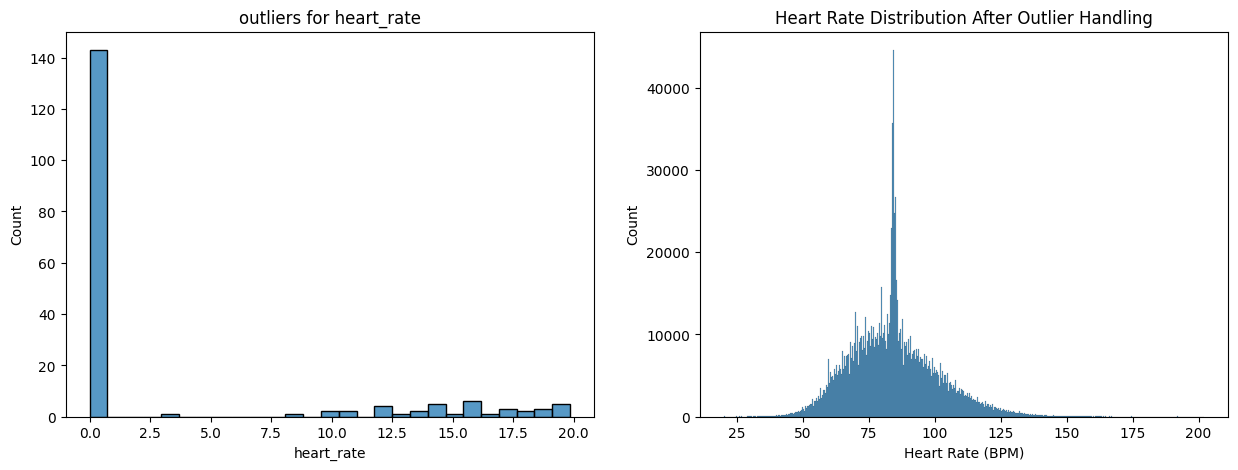

In [8]:
# deal with heart rate outliers
out = data['heart_rate'][(data['heart_rate'] < clinical_ranges['heart_rate'][0]) | (data['heart_rate'] > clinical_ranges['heart_rate'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for heart_rate")

# set very low heart rates to 20
data.loc[(data['heart_rate'] < 20) & (data['heart_rate'] > 7.5), 'heart_rate'] = 20

# forward fill and then backfill heart rates below 7.5
data.loc[(data['heart_rate'] < 7.5), 'heart_rate'] = np.nan
data['heart_rate'] = data.groupby('stay_id')['heart_rate'].ffill()
data['heart_rate'] = data.groupby('stay_id')['heart_rate'].bfill()

sns.histplot(data['heart_rate'], ax=ax[1])
ax[1].set_title('Heart Rate Distribution After Outlier Handling')
ax[1].set_xlabel('Heart Rate (BPM)')
plt.show()

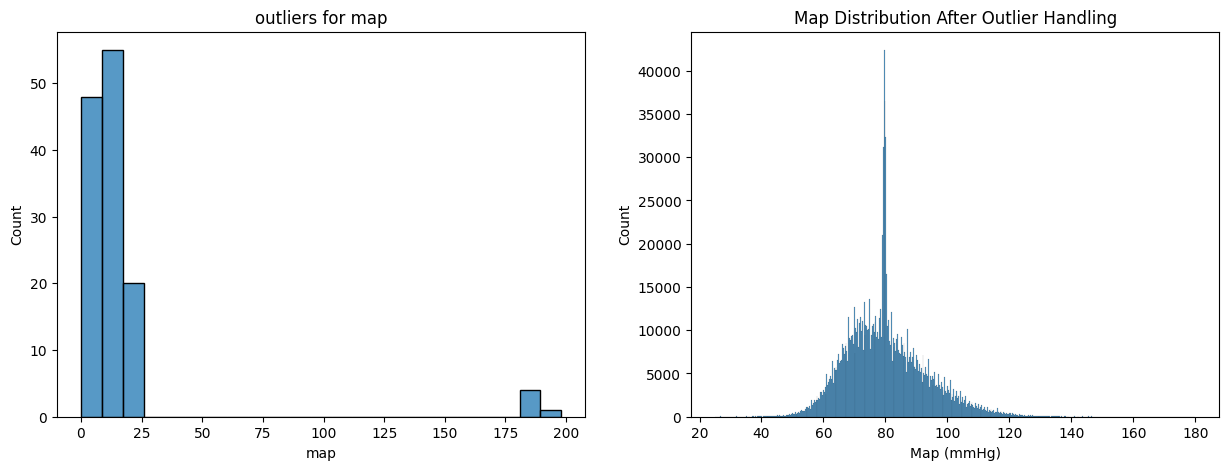

In [9]:
# deal with map outliers

out = data['map'][(data['map'] < clinical_ranges['map'][0]) | (data['map'] > clinical_ranges['map'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for map")

# for the low values, we forward fill and backfill (below 25)
data.loc[(data['map'] < 25), 'map'] = np.nan
data['map'] = data.groupby('stay_id')['map'].ffill()
data['map'] = data.groupby('stay_id')['map'].bfill()

# for the very high values, we set to 180 (above 180)
data.loc[data['map'] > 180, 'map'] = 180

sns.histplot(data['map'], ax=ax[1])
ax[1].set_title('Map Distribution After Outlier Handling')
ax[1].set_xlabel('Map (mmHg)')
plt.show()

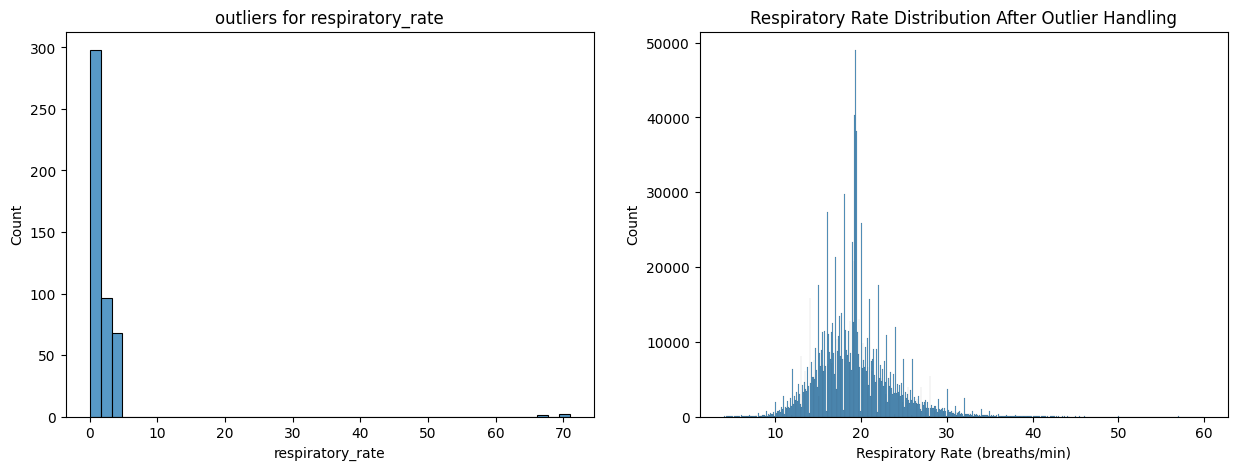

In [10]:
# deal with respiratory_rate outliers

out = data['respiratory_rate'][(data['respiratory_rate'] < clinical_ranges['respiratory_rate'][0]) | (data['respiratory_rate'] > clinical_ranges['respiratory_rate'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for respiratory_rate")

# for low vales, we forward fill and backfill
data.loc[(data['respiratory_rate'] < 4), 'respiratory_rate'] = np.nan
data['respiratory_rate'] = data.groupby('stay_id')['respiratory_rate'].ffill()
data['respiratory_rate'] = data.groupby('stay_id')['respiratory_rate'].bfill()

# for high values, we set to 60
data.loc[data['respiratory_rate'] > 60, 'respiratory_rate'] = 60

sns.histplot(data['respiratory_rate'], ax=ax[1])
ax[1].set_title('Respiratory Rate Distribution After Outlier Handling')
ax[1].set_xlabel('Respiratory Rate (breaths/min)')
plt.show()

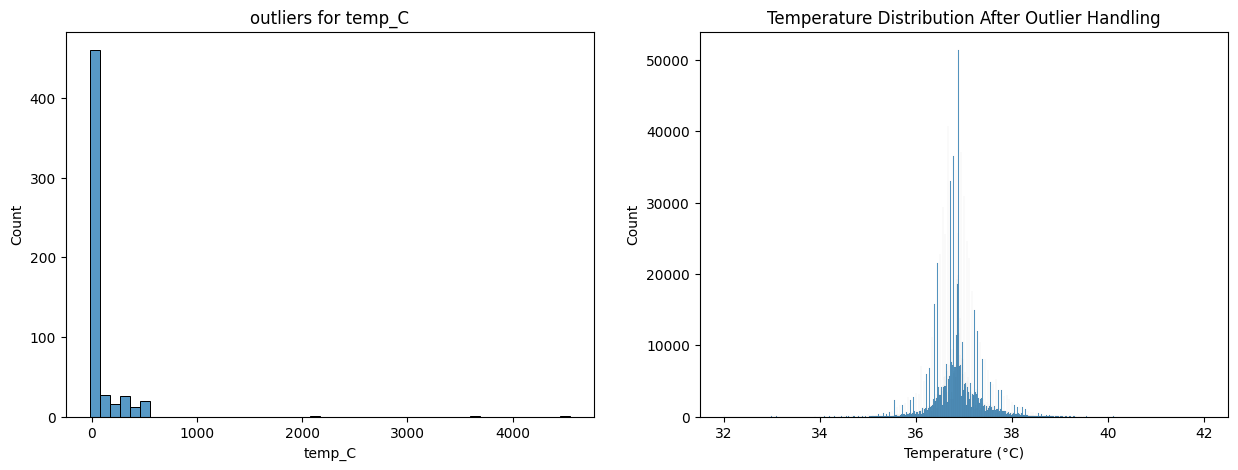

In [11]:
# deal with temp_C outliers

out = data['temp_C'][(data['temp_C'] < clinical_ranges['temp_C'][0]) | (data['temp_C'] > clinical_ranges['temp_C'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for temp_C")

# convert any Fahrenheit records (e.g. 90F to 115F -> ~32C to 46C)
f_mask = (data['temp_C'] >= 90) & (data['temp_C'] <= 115)
data.loc[f_mask, 'temp_C'] = (data.loc[f_mask, 'temp_C'] - 32) / 1.8

# for impossible values forward fill and backfill
data.loc[(data['temp_C'] < 25) | (data['temp_C'] > 45), 'temp_C'] = np.nan
data['temp_C'] = data.groupby('stay_id')['temp_C'].ffill()
data['temp_C'] = data.groupby('stay_id')['temp_C'].bfill()

# clip the extremes to you range
data.loc[data['temp_C'] < 32, 'temp_C'] = 32
data.loc[data['temp_C'] > 42, 'temp_C'] = 42

sns.histplot(data['temp_C'], ax=ax[1])
ax[1].set_title('Temperature Distribution After Outlier Handling')
ax[1].set_xlabel('Temperature (°C)')
plt.show()

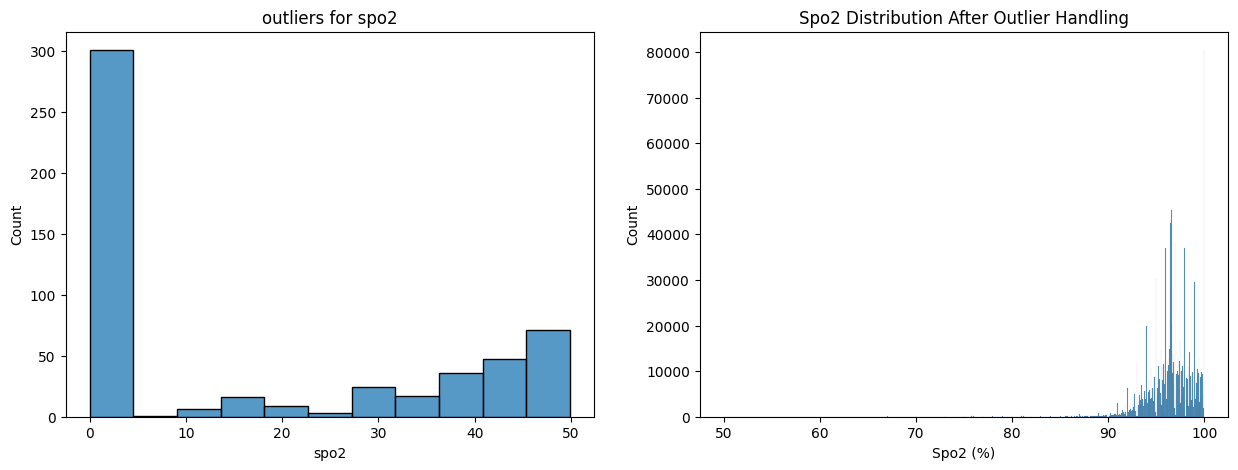

In [12]:
# deal with spo2 outliers

out = data['spo2'][(data['spo2'] < clinical_ranges['spo2'][0]) | (data['spo2'] > clinical_ranges['spo2'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for spo2")

# all values below 50 are foward and back filled
data.loc[data['spo2'] < 50, 'spo2'] = np.nan
data['spo2'] = data.groupby('stay_id')['spo2'].ffill()
data['spo2'] = data.groupby('stay_id')['spo2'].bfill()

sns.histplot(data['spo2'], ax=ax[1])
ax[1].set_title('Spo2 Distribution After Outlier Handling')
ax[1].set_xlabel('Spo2 (%)')
plt.show()

number of wbc with 0 values: 0


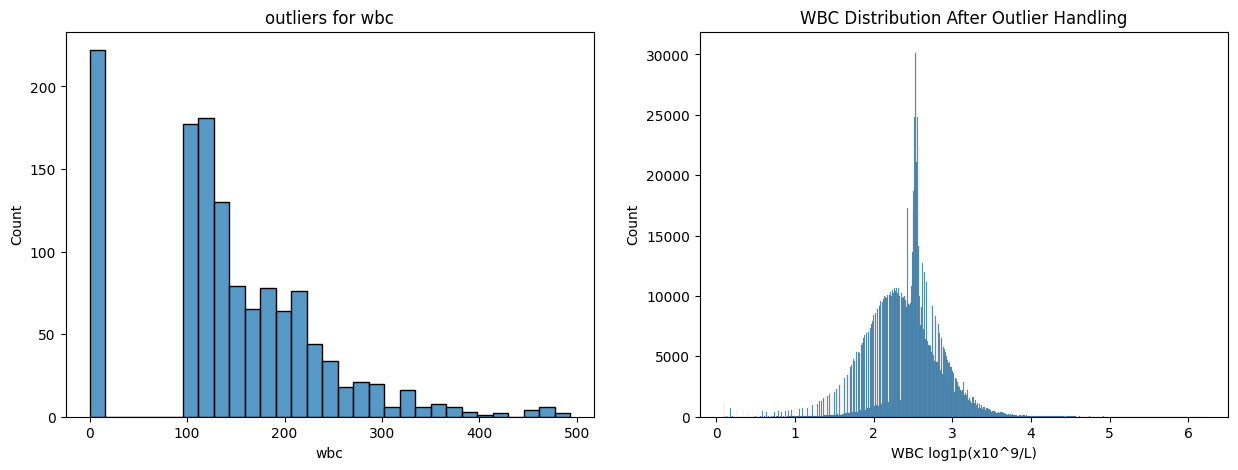

In [13]:
# deal with wbc outliers

out = data['wbc'][(data['wbc'] < clinical_ranges['wbc'][0]) | (data['wbc'] > clinical_ranges['wbc'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for wbc")


print(f'number of wbc with 0 values: {(data["wbc"] == 0).sum()}')

# log1p to compress the right-skewed tail (100-500 range)
data.loc[data['wbc'] < 0.1, 'wbc'] = 0.1 # avoid issues with log transform
data['wbc'] = np.log1p(data['wbc'])

sns.histplot(data['wbc'], ax=ax[1])
ax[1].set_title('WBC Distribution After Outlier Handling')
ax[1].set_xlabel('WBC log1p(x10^9/L)')

plt.show()

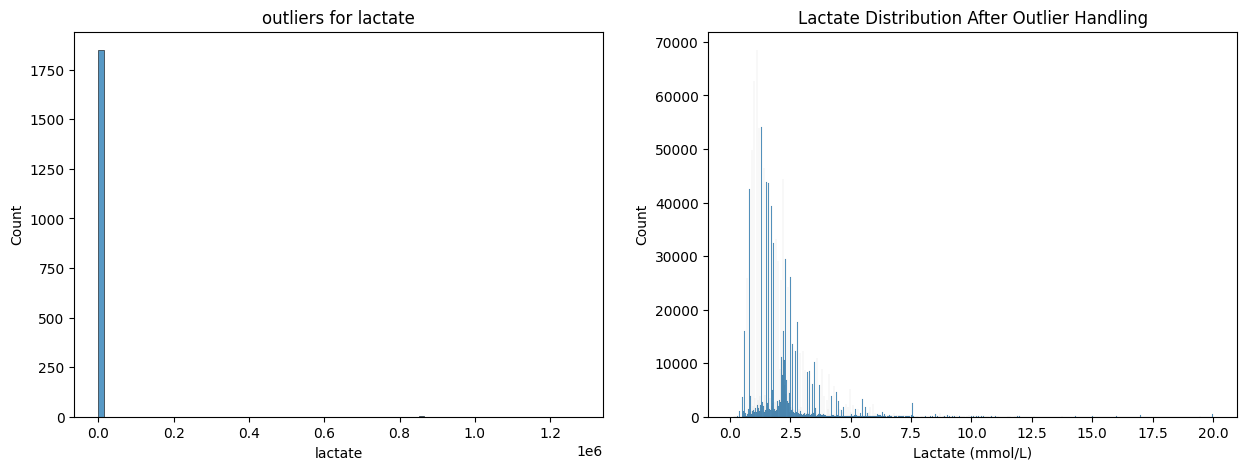

In [14]:
# deal with lactate outliers

out = data['lactate'][(data['lactate'] < clinical_ranges['lactate'][0]) | (data['lactate'] > clinical_ranges['lactate'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for lactate")

# replace 0s or values above 20 with NaN, then forward and back fill
data.loc[(data['lactate'] < 0.1) | (data['lactate'] > 20), 'lactate'] = np.nan
data['lactate'] = data.groupby('stay_id')['lactate'].ffill()
data['lactate'] = data.groupby('stay_id')['lactate'].bfill()

sns.histplot(data['lactate'], ax=ax[1])
ax[1].set_title('Lactate Distribution After Outlier Handling')
ax[1].set_xlabel('Lactate (mmol/L)')

plt.show()

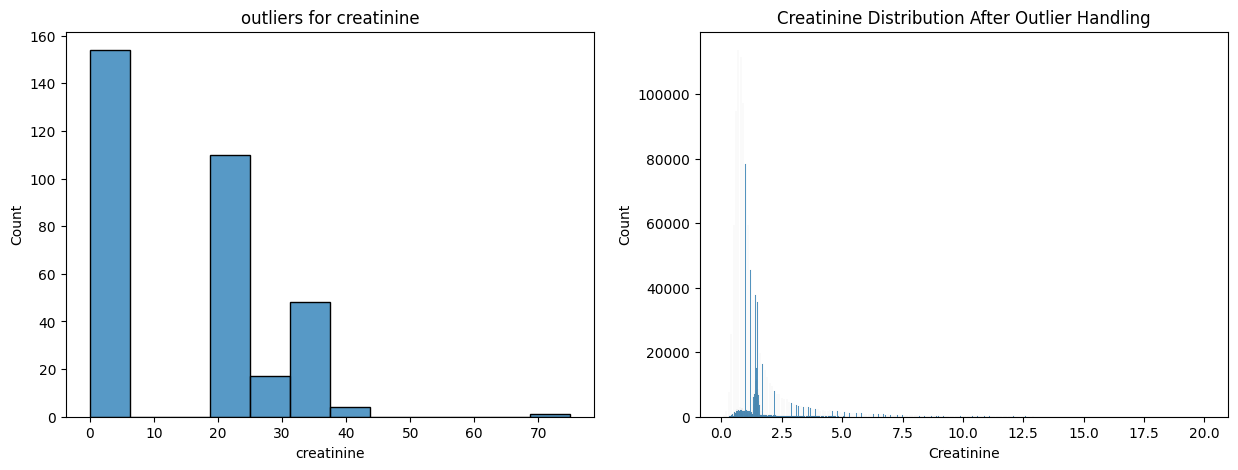

In [15]:
# deal with creatinine outliers

out = data['creatinine'][(data['creatinine'] < clinical_ranges['creatinine'][0]) | (data['creatinine'] > clinical_ranges['creatinine'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for creatinine")

# forward/back-fill values less than 0.1 or above 20
data.loc[(data['creatinine'] < 0.1) | (data['creatinine'] > 20), 'creatinine'] = np.nan
data['creatinine'] = data.groupby('stay_id')['creatinine'].ffill()
data['creatinine'] = data.groupby('stay_id')['creatinine'].bfill()

sns.histplot(data['creatinine'], ax=ax[1])
ax[1].set_title('Creatinine Distribution After Outlier Handling')
ax[1].set_xlabel('Creatinine')

plt.show()

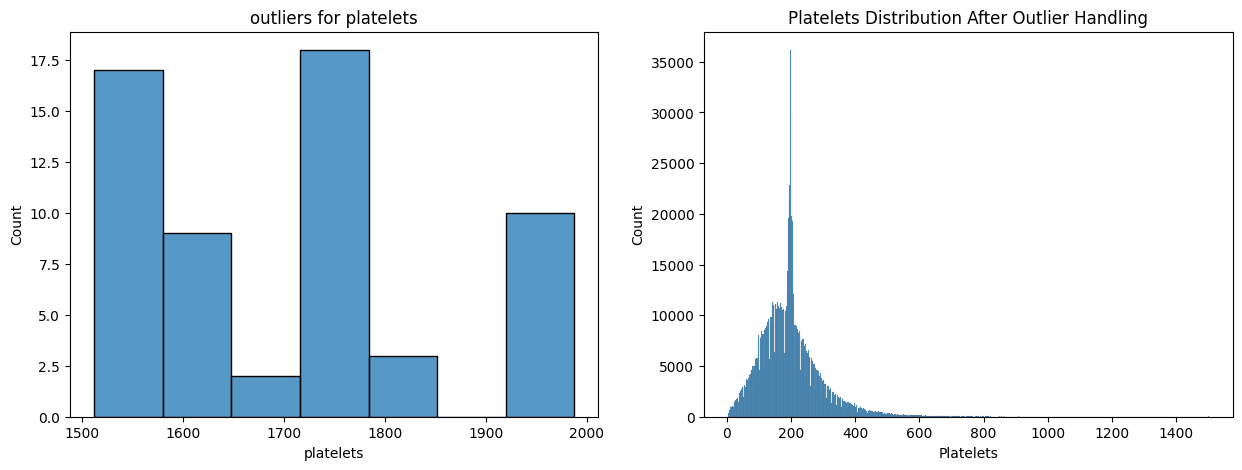

In [16]:
# deal with platelets outliers

out = data['platelets'][(data['platelets'] < clinical_ranges['platelets'][0]) | (data['platelets'] > clinical_ranges['platelets'][1])]

fig, ax = plt.subplots(1,2, figsize=(15, 5))

sns.histplot(out, ax=ax[0])
ax[0].set_title(f"outliers for platelets")

# cap at 1500
data.loc[data['platelets'] > 1500, 'platelets'] = 1500

sns.histplot(data['platelets'], ax=ax[1])
ax[1].set_title('Platelets Distribution After Outlier Handling')
ax[1].set_xlabel('Platelets')

plt.show()

In [17]:
print("missing values after all transformations:" + str(data.isnull().sum().sum()))
print()
# we look at how many stay ids still have missing values.
print('stay_id with missing values:')
print(data[data.isnull().any(axis=1)].index.get_level_values('stay_id').unique().values)
print()
# remove the 2 stays with missing vlas
data = data[~data.index.get_level_values('stay_id').isin(data[data.isnull().any(axis=1)].index.get_level_values('stay_id').unique())]

print("final missing values :", data.isnull().sum().sum())

missing values after all transformations:25

stay_id with missing values:
[30663318 30663426]

final missing values : 0


In [18]:
#datatype check
print(data.dtypes)

sepsis                          int64
age                           float64
gender                          int64
charlson_comorbidity_index      int64
heart_rate                    float64
map                           float64
respiratory_rate              float64
temp_C                        float64
spo2                          float64
wbc                           float64
lactate                       float64
creatinine                    float64
platelets                     float64
sirs_score                      int64
shock_index                   float64
dtype: object


In [19]:
# check for duplicates
duplicates = data.index.duplicated().sum()
print(f"Duplicate (stay_id, timestep) combinations: {duplicates}")

Duplicate (stay_id, timestep) combinations: 0


In [20]:
# check for timestep continuity within each stay_id
continuous = True
for stay_id in data.index.get_level_values('stay_id').unique()[:10]:  # sample check
    timesteps = data.loc[stay_id].index.tolist()
    if timesteps != list(range(timesteps[0], timesteps[-1] + 1)):
        print(f"Stay {stay_id} has gaps in timesteps: {timesteps}")
        continuous = False
if continuous:
    print("All checked stays have continuous timesteps without gaps.")

All checked stays have continuous timesteps without gaps.


In [21]:
# save the cleaned data
data.to_parquet('../../data/processed_files/patient_timeseries_cleaned.parquet')